<a href="https://colab.research.google.com/github/bmxjuane/Juan-Emilio-Persichini-Data-Science-2/blob/main/Data_Science_2_(primera_entrega)5-8-2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Disease Risk from Daily Habits**

Este dataset contiene informacion detallada acerca de habitos, metricas de salud, estilo de vida y datos biometricos de 35.000 individuos con 23 variables y un objetivo, predecir si la persona tiene mas chances de tener una enfermedad de acuerdo a ciertas variables. El conjunto de datos incluye variables numéricas como edad, altura, peso, presión arterial, colesterol, glucosa, entre otras; y variables categóricas como género, tipo de dieta, nivel de ejercicio, historial familiar, etc.
Este análisis exploratorio busca identificar patrones, correlaciones y posibles factores de riesgo que puedan influir en el desarrollo de enfermedades.



# **Descripcion de las variables**

 **Datos personales y demográficos**

- survey_code: Identificador único de cada encuesta.
- age: Edad del encuestado.
- gender: Género (por ejemplo, masculino, femenino, otro).
- pet_owner: Si la persona tiene mascotas.
- family_history: Antecedentes familiares de enfermedades.

 **Medidas físicas y biométricas**

- height: Altura en metros o centímetros.
- weight: Peso en kilogramos.
- blood_pressure: Presión arterial.
- heart_rate: Frecuencia cardíaca.
- cholesterol: Nivel de colesterol.
- glucose: Nivel de glucosa.
- insulin: Nivel de insulina.

 **Hábitos diarios**

- sleep_hours: Horas de sueño por día.
- physical_activity: Nivel de actividad física (minutos o escala).
- daily_steps: Cantidad de pasos diarios.
- screen_time: Tiempo frente a pantallas.
- water_intake: Consumo de agua diario.
- caffeine_intake: Consumo de cafeína (ej. bajo, medio, alto).
- calorie_intake: Ingesta calórica diaria.
- sugar_intake: Consumo de azúcar diario.
- alcohol_consumption: Consumo de alcohol (ej. nunca, ocasional, frecuente).
- smoking_level: Nivel de tabaquismo.
- diet_type: Tipo de dieta (ej. vegetariana, balanceada, alta en grasas).
- exercise_type: Tipo de ejercicio realizado.



- target: Variable objetivo (probablemente indica si la persona tiene riesgo de enfermedad o no).

Como primera medida vamos a importar las librerias que vamos a utilizar

In [65]:
import numpy as np
import pandas as pd
import os
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt

In [64]:
df = pd.read_csv('/content/health_lifestyle.csv')

In [63]:
df.head(5)

,survey_code,age,gender,height,weight,blood_pressure,heart_rate,cholesterol,glucose,insulin,...,calorie_intake,sugar_intake,smoking_level,water_intake,screen_time,diet_type,exercise_type,family_history,pet_owner,target
0,1,56,Male,173.416872,56.886640,118.264254,60.749825,214.580523,103.008176,NaN,...,2673.546960,44.476887,Non-smoker,1.694262,5.003963,Vegan,Strength,No,Yes,healthy
1,2,69,Female,163.207380,97.799859,117.917986,66.463696,115.794002,116.905134,10.131597,...,2650.376972,74.663405,Light,0.716409,5.925455,Vegan,Cardio,Yes,No,healthy
2,3,46,Male,177.281966,80.687562,123.073698,76.043212,138.134787,89.180302,NaN,...,1746.755144,19.702382,Heavy,2.487900,4.371250,Vegan,Cardio,No,No,healthy
3,4,32,Female,172.101255,63.142868,148.173453,68.781981,203.017447,128.375798,18.733179,...,2034.193242,82.580050,Heavy,2.643335,4.116064,Vegetarian,Mixed,No,Yes,healthy
4,5,60,Female,163.608816,70.000000,150.613180,92.335358,200.412439,94.813332,16.038701,...,2386.210257,45.961322,Heavy,1.968393,3.180087,Vegan,NaN,Yes,Yes,healthy


Vamos a analizar la variable "weight" y ver si tenemos outliers que puedan afectar el analisis.

In [66]:
conteo_kilos = (df['weight'] <= 42).sum()
print (conteo_kilos)

1083


Tenemos 1083 casos que no superan los 42 kilos (minimo establecido lo que se entiende como un error para el objetivo de analisis que estamos haciendo ya que ese peso puede obedecer a enfermedades ya preexistentes.

Lo que vamos a hacer es reemplazar todos los casos en que el peso es menor a 42 por el peso mas repetido que es 70

In [69]:
print(df['weight'].describe())

count    35000.000000
mean        71.024323
std         13.778862
min         42.002238
25%         61.236760
50%         70.000000
75%         80.132626
max        133.799980
Name: weight, dtype: float64


In [70]:
condicion = df['weight'] < 42
df.loc[condicion, 'weight'] = 70

In [71]:
print(df['weight'].describe())

count    35000.000000
mean        71.024323
std         13.778862
min         42.002238
25%         61.236760
50%         70.000000
75%         80.132626
max        133.799980
Name: weight, dtype: float64


In [72]:
df.columns

Index(['survey_code', 'age', 'gender', 'height', 'weight', 'blood_pressure',
       'heart_rate', 'cholesterol', 'glucose', 'insulin', 'sleep_hours',
       'work_hours', 'physical_activity', 'daily_steps', 'calorie_intake',
       'sugar_intake', 'alcohol_consumption', 'smoking_level', 'water_intake',
       'screen_time', 'diet_type', 'exercise_type', 'family_history',
       'pet_owner', 'target'],
      dtype='object')

In [73]:
df.shape

(35000, 25)

In [74]:
# Resumen estadistico de las variables categoricas
df.describe(include=['object']).T

,count,unique,top,freq
gender,35000,2,Female,17545
alcohol_consumption,20198,2,Occasionally,10114
smoking_level,35000,3,Heavy,11724
diet_type,35000,4,Vegan,8924
exercise_type,26208,3,Strength,8808
family_history,35000,2,Yes,17620
pet_owner,35000,2,No,17691
target,35000,2,healthy,24621


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   survey_code          35000 non-null  int64  
 1   age                  35000 non-null  int64  
 2   gender               35000 non-null  object 
 3   height               35000 non-null  float64
 4   weight               35000 non-null  float64
 5   blood_pressure       32290 non-null  float64
 6   heart_rate           30074 non-null  float64
 7   cholesterol          35000 non-null  float64
 8   glucose              35000 non-null  float64
 9   insulin              29459 non-null  float64
 10  sleep_hours          35000 non-null  float64
 11  work_hours           35000 non-null  float64
 12  physical_activity    35000 non-null  float64
 13  daily_steps          32083 non-null  float64
 14  calorie_intake       35000 non-null  float64
 15  sugar_intake         35000 non-null 

In [16]:
# Verificamos que cantidad de valores nulos hay en cada columna (variable)
df.isnull().sum()

,0
survey_code,0
age,0
gender,0
height,0
weight,0
blood_pressure,2710
heart_rate,4926
cholesterol,0
glucose,0
insulin,5541


La variable "alcohol_consumption" tiene aproximadamente un 40% de valores nulos, procederemos a eliminarla ya que es un porcentaje alto de valores nulos y no es una columna determinante en la busqueda de hipotesis.

In [15]:
df.drop('alcohol_consumption', axis=1, inplace=True)

Ahora procedemos a realizar **analisis univariado** de algunas variables:

In [14]:
print(df['sleep_hours'].describe())

count    35000.000000
mean         7.003034
std          1.488766
min          3.000000
25%          5.994874
50%          7.002513
75%          8.014139
max         12.000000
Name: sleep_hours, dtype: float64


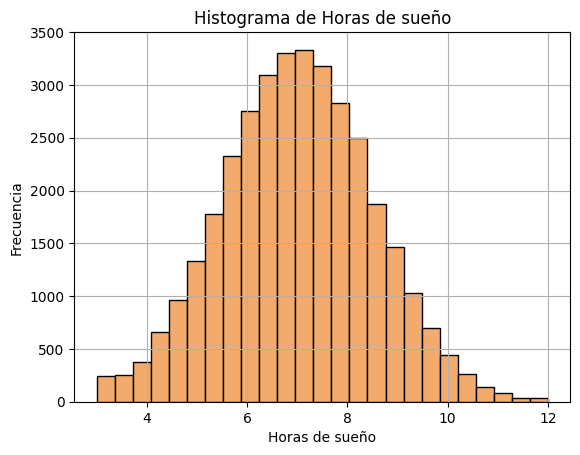

In [13]:
df['sleep_hours'].hist(bins=25, color='#F2AB6D', edgecolor='black')
plt.xlabel('Horas de sueño')
plt.ylabel('Frecuencia')
plt.title('Histograma de Horas de sueño')
plt.grid(True)
plt.show()

Con este grafico podemos afirmar que la mayoria de las personas duerme 7 horas

Ahora veremos analizaremos el tiempo que pasan las personas usando pantallas (celular, computadora, tablet, etc)

In [12]:
print(df['screen_time'].describe())

count    35000.000000
mean         6.020403
std          2.939438
min          0.000000
25%          3.953281
50%          5.985005
75%          8.013358
max         16.000000
Name: screen_time, dtype: float64


¿Cuantos casos hay en los que la persona indicó que no usa pantallas?

In [11]:
conteo_ceros = (df['screen_time'] == 0).sum()
print (conteo_ceros)

772


A continuacion veremos en un histograma, el tiempo que las personas pasan frente a una pantalla y que cantidad de horas es la mas comun.

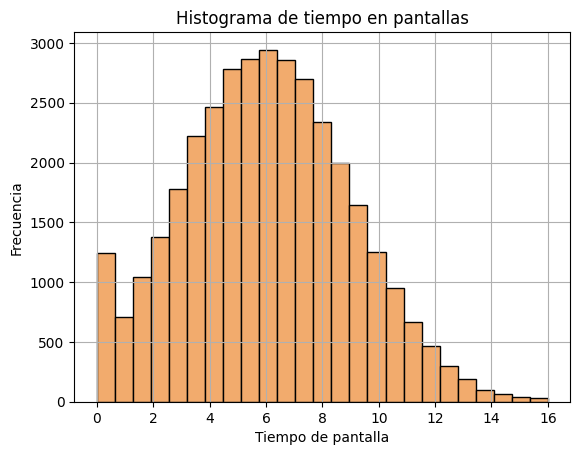

In [77]:
df['screen_time'].hist(bins=25, color='#F2AB6D', edgecolor='black')
plt.xlabel('Tiempo de pantalla')
plt.ylabel('Frecuencia')
plt.title('Histograma de tiempo en pantallas')
plt.grid(True)
plt.show()

La distribucion esta levemente sesgada a la derecha. Podemos afirmar que la mayoria de las personas pasan alrededor de 6hs frente a una pantalla.

Ahora veremos que **tipo de entrenamiento** hacen los individuos estudiados y la cantidad que hay en cada grupo.

In [76]:
print(df['exercise_type'].describe())

count        26208
unique           3
top       Strength
freq          8808
Name: exercise_type, dtype: object


Text(0.5, 1.0, 'Distribución segun tipo de entrenamiento')

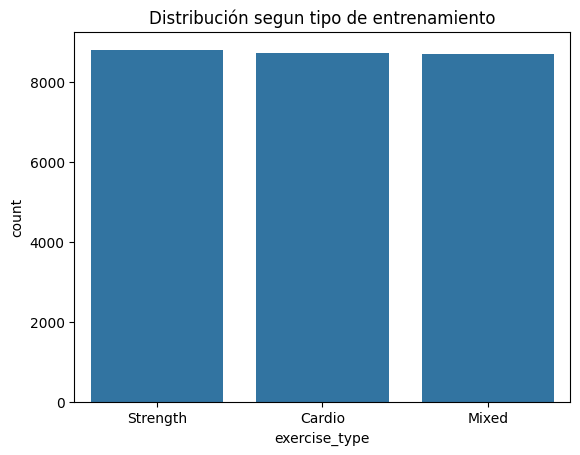

In [80]:
sns.countplot(x='exercise_type', data=df)
plt.title('Distribución segun tipo de entrenamiento')

In [78]:
conteo_grupos = df['exercise_type'].value_counts()
print(conteo_grupos)

exercise_type
Strength    8808
Cardio      8714
Mixed       8686
Name: count, dtype: int64


Luego vamos a ver que tipo de ejercicio se repite mas entre hombres y mujeres

Text(0, 0.5, 'Cantidad de Personas')

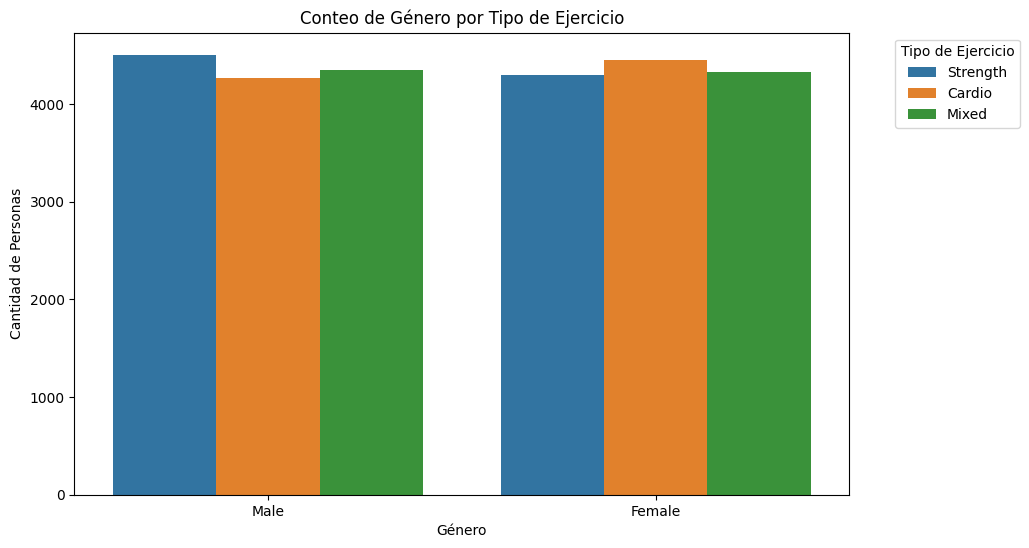

In [79]:
plt.figure(figsize=(10, 6))
sns.countplot(x='gender', hue='exercise_type', data=df)
plt.legend(title='Tipo de Ejercicio', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Conteo de Género por Tipo de Ejercicio')
plt.xlabel('Género')
plt.ylabel('Cantidad de Personas')

Podemos determinar el entrenamiento mas elegido por los hombres es el de fuerza y por las mujeres el cardio

Veremos otro grafico que detalla la cantidad exacta de individuos segun el tipo de ejercicio que practican.

<Axes: xlabel='gender', ylabel='exercise_type'>

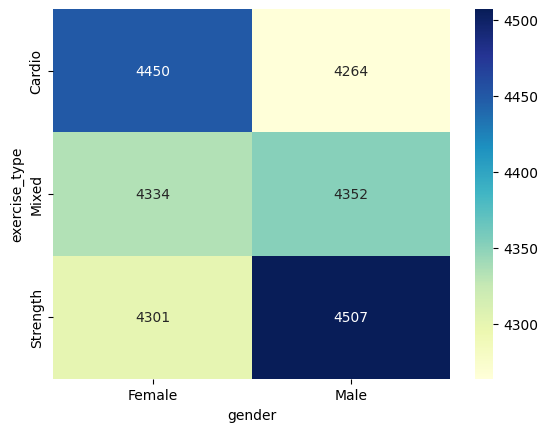

In [51]:
tabla_crosstab = pd.crosstab(df['exercise_type'], df['gender']); sns.heatmap(tabla_crosstab, annot=True, fmt='d', cmap='YlGnBu')